---
title: Finite Markov chains
---

::: { .callout-warning }

## Under Construction

This notebook is under development

:::

In [1]:
from phasic import Graph, with_ipv # ALWAYS import phasic first to set jax backend correctly
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from vscodenb import set_vscode_theme

np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

### Distribution of steps spent in a state

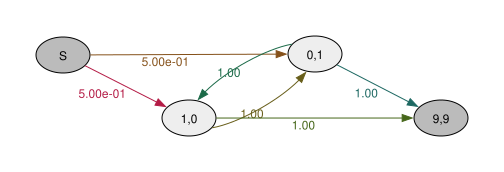

In [2]:
@with_ipv([([1, 0], 0.5), ([0, 1], 0.5)])
def loop(state):
    transitions = []

    if state.sum() > 1:
        return transitions

    if state[0] == 0:
        new_state = state.copy()
        new_state[0] += 1
        new_state[1] -= 1            
        transitions.append((new_state, 1))
    else:
        new_state = state.copy()
        new_state[0] -= 1
        new_state[1] += 1
        transitions.append((new_state, 1))

    new_state = state.copy()
    new_state[0] = 9
    new_state[1] = 9
    transitions.append((new_state, 1))

    return transitions

graph = Graph(loop)

graph.plot()


In [3]:
def loop_reward_rates(new_state, current_rewards=None, mutation_rate=None, reward_limit=10, tot_reward_limit=5):

    target_state = np.array([0, 1])

    # reward_limits = np.append(np.repeat(reward_limit, len(new_state)-1), 0)
    reward_limits = np.repeat(reward_limit, len(new_state))
    
    reward_dims = len(reward_limits)
    if current_rewards is None:
        current_rewards = np.zeros(reward_dims)

    result = np.zeros(reward_dims)
    trash_rate = 0
    
    for i in range(reward_dims):
        rate = new_state[i] * mutation_rate 
        r = np.zeros(reward_dims)
        r[i] = 1
        
        if np.all(new_state == target_state) and np.sum(current_rewards + r) <= tot_reward_limit:
        # if np.all(current_rewards + r <= reward_limits) and np.sum(current_rewards + r) <= tot_reward_limit:
            result[i] = rate
        else:
            trash_rate = trash_rate + rate

    return np.append(result, trash_rate)


# # # reward_rates = partial(coalescent_reward_rates, mutation_rate=1, reward_limit=1, tot_reward_limit=2)
# # reward_rates = partial(loop_reward_rates, mutation_rate=1, reward_limit=2)

# joint_graph = joint_prob_graph(graph, loop_reward_rates, mutation_rate=1, reward_limit=2)
# joint_probs_table(joint_graph, graph.state_length())
# #joint_probs = discrete_joint_prob(graph, reward_rates)



In [4]:
# discrete_joint_prob(graph, reward_rates, return_graph=True).plot(size=(8, 8), ranksep=1, nodesep=0.5)

### Nr of runs of a particular state

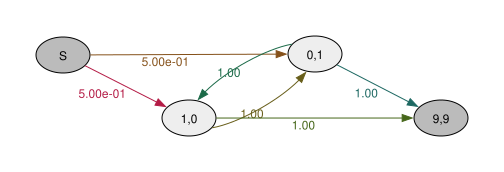

In [5]:
graph = Graph(loop)
graph.plot(rainbow=True)


In [6]:
# from collections import defaultdict

# def make_discrete(graph, mutation_rate, skip_states=[], skip_slots=[]):
#     """
#     Takes a graph for a continuous distribution and turns
#     it into a descrete one (inplace). Returns a matrix of
#     rewards for computing marginal moments
#     """

#     mutation_graph = graph.copy()

#     # save current nr of states in graph
#     vlength = mutation_graph.vertices_length()

#     # number of fields in state vector (assumes all are the same length)
#     state_vector_length = len(mutation_graph.vertex_at(1).state())

#     # list state vector fields to reward at each auxiliary node
#     # rewarded_state_vector_indexes = [[] for _ in range(state_vector_length)]
#     rewarded_state_vector_indexes = defaultdict(list)

#     # loop all but starting node
#     for i in range(1, vlength):
#         if i in skip_states:
#             continue
#         vertex = mutation_graph.vertex_at(i)
#         if vertex.rate() > 0: # not absorbing
#             for j in range(state_vector_length):
#                 if j in skip_slots:
#                     continue
#                 val = vertex.state()[j]
#                 if val > 0: # only ones we may reward
#                     # add auxilliary node
#                     mutation_vertex = mutation_graph.create_vertex(np.repeat(0, state_vector_length))
#                     mutation_vertex.add_edge(vertex, 1)
#                     vertex.add_edge(mutation_vertex, mutation_rate*val)
#                     # print(mutation_vertex.index(), rewarded_state_vector_indexes[j], j)
#                     # rewarded_state_vector_indexes[mutation_vertex.index()] = rewarded_state_vector_indexes[j] + [j]
#                     rewarded_state_vector_indexes[mutation_vertex.index()].append(j)

#     # print(rewarded_state_vector_indexes)

#     # normalize graph
#     weights_were_multiplied_with = mutation_graph.normalize()

#     # build reward matrix
#     rewards = np.zeros((mutation_graph.vertices_length(), state_vector_length))
#     for state in rewarded_state_vector_indexes:
#         for i in rewarded_state_vector_indexes[state]:
#             rewards[state, i] = 1

#     rewards = np.transpose(rewards)
#     return mutation_graph, rewards



In [7]:


# graph = Graph(coalescent)

# mutation_rate = 0.1


# # add auxilliary states, normalize and return reward matrix:
# mutation_vertices = make_discrete(graph, mutation_rate)

# mutation_graph.plot()


After discretization, the expectation should remain:

In [8]:
graph.expectation() * 0.1


0.1

Let's see if that is true.

# FIXME: something is wrong in graph.discretize() 

# Also, should I use dph_normalize() ???

In [9]:
# mutation_graph, rewards = make_discrete(graph, 0.1)
# print(mutation_vertices)
# mutation_graph.plot()

#OR:      --------------------- which is right? ---------------------

# mutation_vertices = graph.discretize(1)
# as_diag = np.diag(mutation_vertices)
# rewards = as_diag[np.nonzero(mutation_vertices)]

# print(rewards)
# mutation_graph.plot()

In [10]:
# mutation_graph.expectation(np.sum(rewards, axis=0))

In [11]:
# sfs = np.apply_along_axis(graph.expectation, 1, rewards)
# sns.barplot(sfs) ;

In [12]:
# sfs = np.apply_along_axis(graph.expectation_discrete, 1, rewards)
# sns.barplot(sfs) ;

In [13]:
# sns.barplot(mutation_graph.pdf(np.arange(10)))
# sns.despine()

In [14]:
# new_graph = graph.copy()

# target_vertex = new_graph.vertex_at(5)

# new_vertices = []
# for vertex in new_graph.vertices():
#     for edge in vertex.edges():
#         if edge.to() == target_vertex:
#             # create new vertex
#             new_vertex = new_graph.find_or_create_vertex(np.repeat(-vertex.index(), vertex.state().size))

#             # make edge point that instead
#             edge.update_to(new_vertex)

#             # add edge from new_vertex to target_vertex with weight 1
#             new_vertex.add_edge(target_vertex, 1)

#             # keep index of added vertex
#             new_vertices.append(new_vertex.index())

# # rewards = make_discrete(new_graph, mutation_rate, skip=new_vertices)
# rewards = make_discrete(new_graph, 1, skip_states=new_vertices)

# print(rewards)

# rev = np.zeros(new_graph.vertices_length())
# for i in new_vertices:
#     rev[i] = 1

# print(new_graph.expectation(rev))
# # print(new_graph.accumulated_occupancy(10))
# print(new_graph.accumulated_visits_discrete(1000))

# new_graph.plot(rainbow=True, size=(10, 10))


In [15]:
# def loop(state):
#     if not state.size:
#         return [([1], 1)]
#     elif state[0] < 3:
#         return [(state+1, 4)]
#     return []

# graph = Graph(loop)
# graph.plot()

In [16]:
# graph.expectation(), graph.expected_waiting_time()

In [17]:

# discr_graph, discr_rewards = graph.discretize(rate=1)
# discr_graph.plot()


In [18]:
# np.sum(discr_rewards, axis=0)

In [19]:
# discr_graph.expected_waiting_time()

In [20]:
# discr_graph.expectation(np.sum(discr_rewards, axis=0))

In [21]:
# np.sum(discr_rewards, axis=0)

In [22]:
# discr_graph.expectation(discr_rewards)


In [23]:
# graph.expectation(np.sum(discr_rewards, axis=1))

In [24]:
# discr_graph.expectation(rewards = np.sum(discr_rewards, axis=1))
# #graph.expectation(np.sum(discr_rewards, axis=1) * 0.1)




In [25]:
# def loop():

#     def callback(state):
#         transitions = []
#         if state[0] == 0:
#             new_state = state[:]
#             new_state[0] += 1
#             new_state[1] -= 1
#             transitions.append((new_state, 1))
#         else:
#             new_state = state[:]
#             new_state[0] -= 1
#             new_state[1] += 1
#             transitions.append((new_state, 1))
#         return transitions

#     graph = Graph(callback, initial=[1, 0])
#     return graph
        
# graph = loop()
# graph.plot(rainbow=True)

### I could add an fmc argument that adds a slot to initial and increments that for all states returned by callback

In [26]:
# def loop():

#     def callback(state):

#         if not state.size:
#             return [([1, 0, 0], 1)]

#         if state[2] == 5:
#             return []

#         if state[0] == 0:
#             new_state = state[:]
#             new_state[0] += 1
#             new_state[1] -= 1
#             new_state[2] += 1
#             return [(new_state, 1)]
#         else:
#             new_state = state[:]
#             new_state[0] -= 1
#             new_state[1] += 1
#             new_state[2] += 1
#             return [(new_state, 1)]

#     graph = Graph(callback)
#     return graph
        
# graph = loop()
# graph.plot(rainbow=True)

In [27]:
# rewards = make_discrete(graph, 1, skip_slots=[graph.state_length()-1])
# graph.plot(rainbow=True)


In [28]:
# graph.states()

In [29]:
# graph.accumulated_visits_discrete(1000)


### Length of longest run of a state in an FMC

In [30]:
# # D: A->A
# # A: A->B
# # B: B->A
# # D: B->B

# def maxlen():

#     def callback(state):

#         A, B, C, D = 1, 1, 1, 1

#         if not state.size:
#             return [([1, 0, 0], 1)]

#         x, y, z = state
        
#         max_y, max_z = 2, 6

#         absorb = (0, max_y, max_z)
#         # absorb = (0, 0, 0)
#         if np.all(state == absorb):
#             return []

#         trash1, trash2 = (-1, -1, -1), (-2, -2, -2)
#         # trash1, trash2 = (0, 0, 0), (0, 0, 0)
#         if np.all(state == trash1):
#             return [(trash2, 1)]
#         if np.all(state == trash2):
#             return [(trash1, 1)]

#         if z+1 == max_z:
#             return [(absorb, 1)]
        
#         if y == 0:
#             return [((x, y, z+1), C/(B+C)),
#                     ((x, y+1, z+1), A/(A+D))]
#         if y == max_y:
#             return [(trash1, D/(A+D)), # trash
#                     ((y, 0, z+1), B/(B+C))]

#         return [((x, y+1, z+1), D/(A+D)),
#                 ((y, 0, z+1), B/(B+C))]

#     graph = Graph(callback)
#     return graph
        
# graph = maxlen()
# graph.plot(rainbow=True, ranksep=1, nodesep=0.3, size=(10, 10))

In [31]:
# graph.states()

With `sample_size <- 4`, `mutation_rate <- 1`, `reward_limits <- rep(20, sample_size-1)`, and `tot_reward_limit <- Inf`, tothe marginal probabilities match the SFS:

```
c(sum(joint_probs$V1 * joint_probs$accum_time), 
  sum(joint_probs$V2 * joint_probs$accum_time), 
  sum(joint_probs$V3 * joint_probs$accum_time))
```

```
1.99981743759578 0.998152771395828 0.666638375487117
```

and the joint prob of a singleton and a trippleton is:

```
1	0	1	0.03111111
```

which is exactly what we also get with `reward_limits <- rep(1, sample_size-1)`.

Setting `tot_reward_limit <- 2` also produces `0.03111111`.

In [32]:
# joint_probs %>% rename_with(gsub, pattern="V", replacement="ton") %>% group_by(ton1, ton2) %>% summarize(prob=sum(accum_time), .groups="keep")